In [1]:
#!/usr/bin/env python3
"""
Visual debugging for L1C cloud detection
"""

import ee
import numpy as np#!/usr/bin/env python3
"""
Debug cloud mask visually
"""

import ee
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

from download_sentinel2 import initialize_earthengine, create_l1c_cloud_mask

initialize_earthengine()

Total images: 4

IMAGE 1: 2023-05-01
Cloud fraction: 100.0%
Decision: REJECT ✗


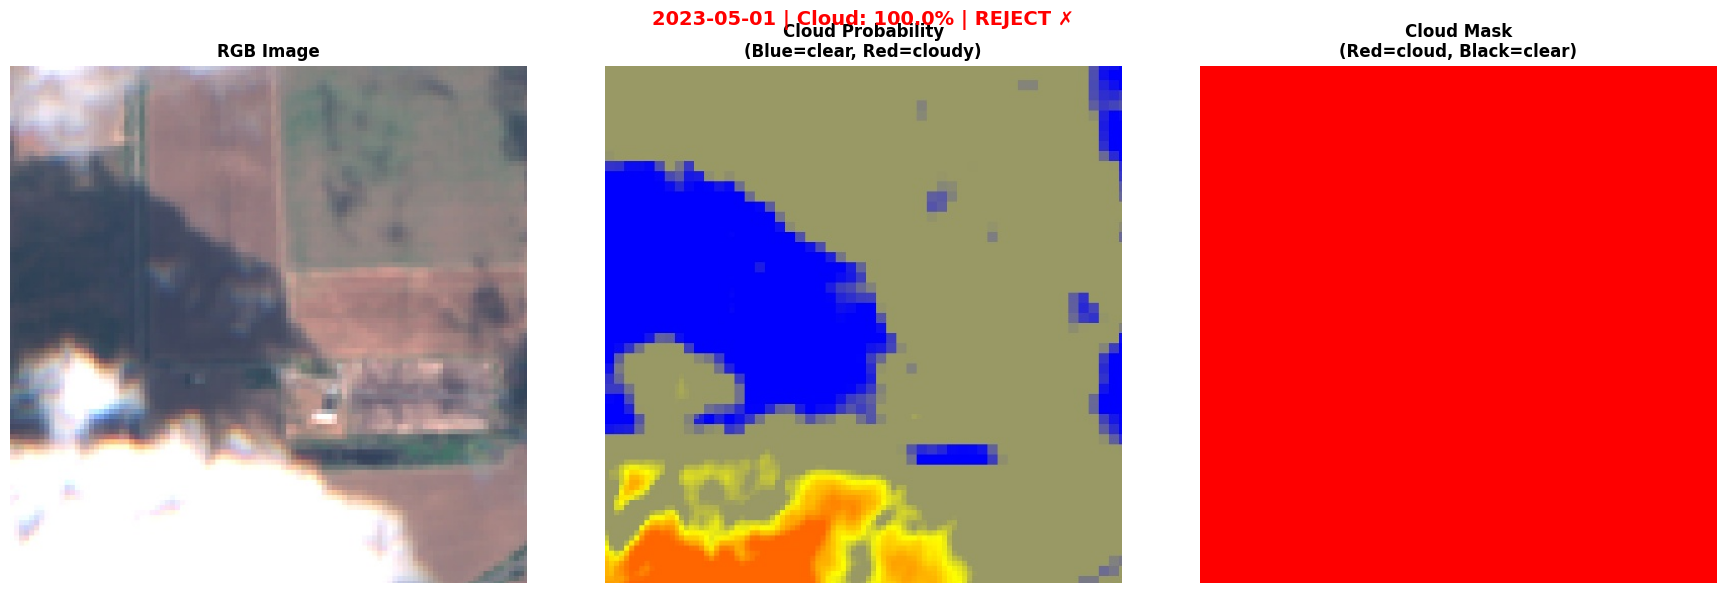


IMAGE 2: 2023-05-04
Cloud fraction: 100.0%
Decision: REJECT ✗


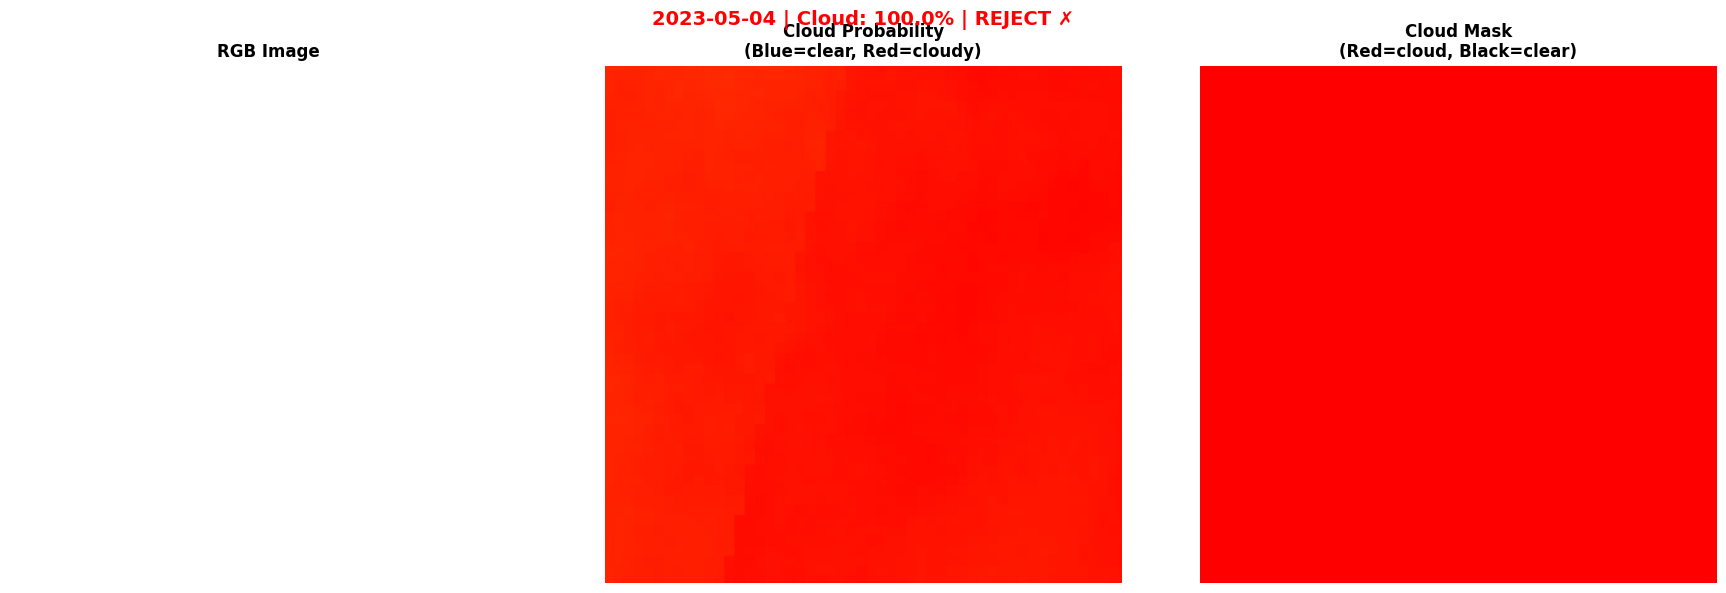


IMAGE 3: 2023-05-06
Cloud fraction: 100.0%
Decision: REJECT ✗


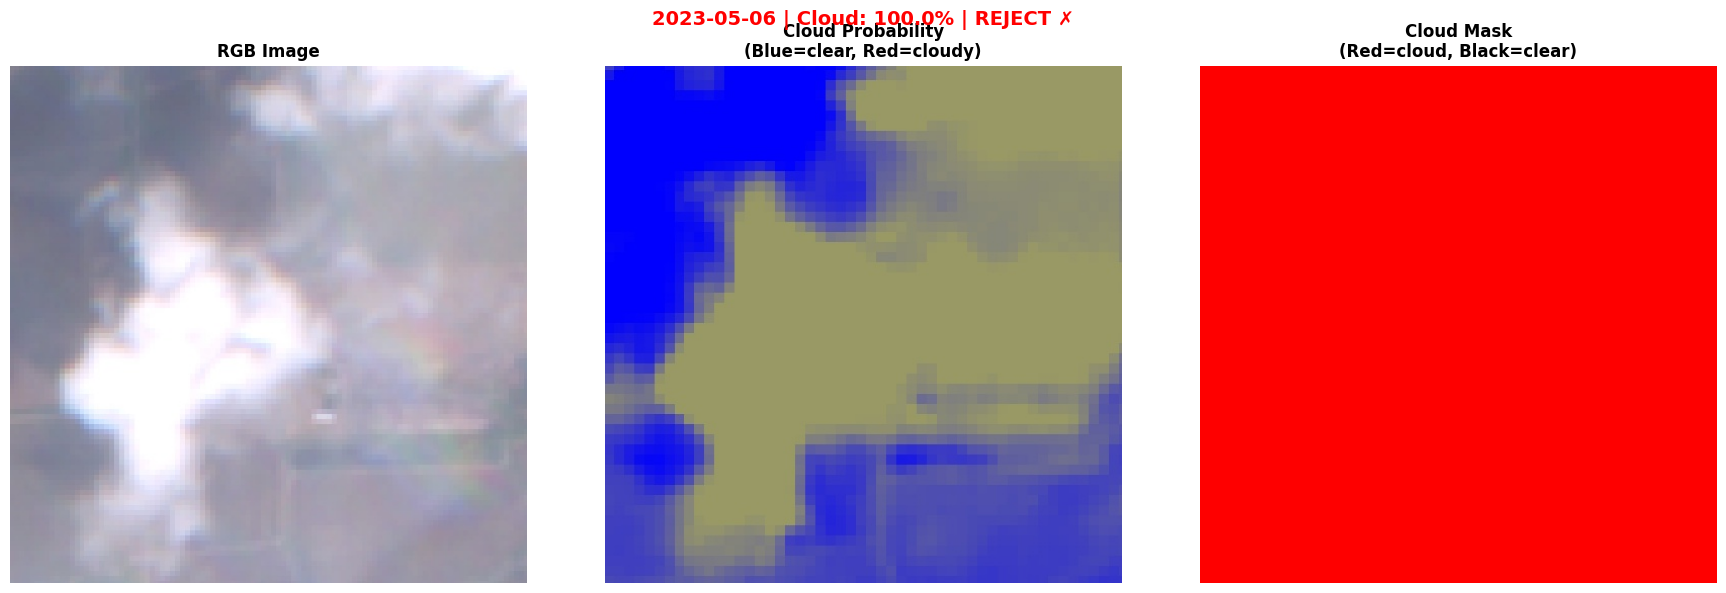


IMAGE 4: 2023-05-09
Cloud fraction: 0.0%
Decision: KEEP ✓


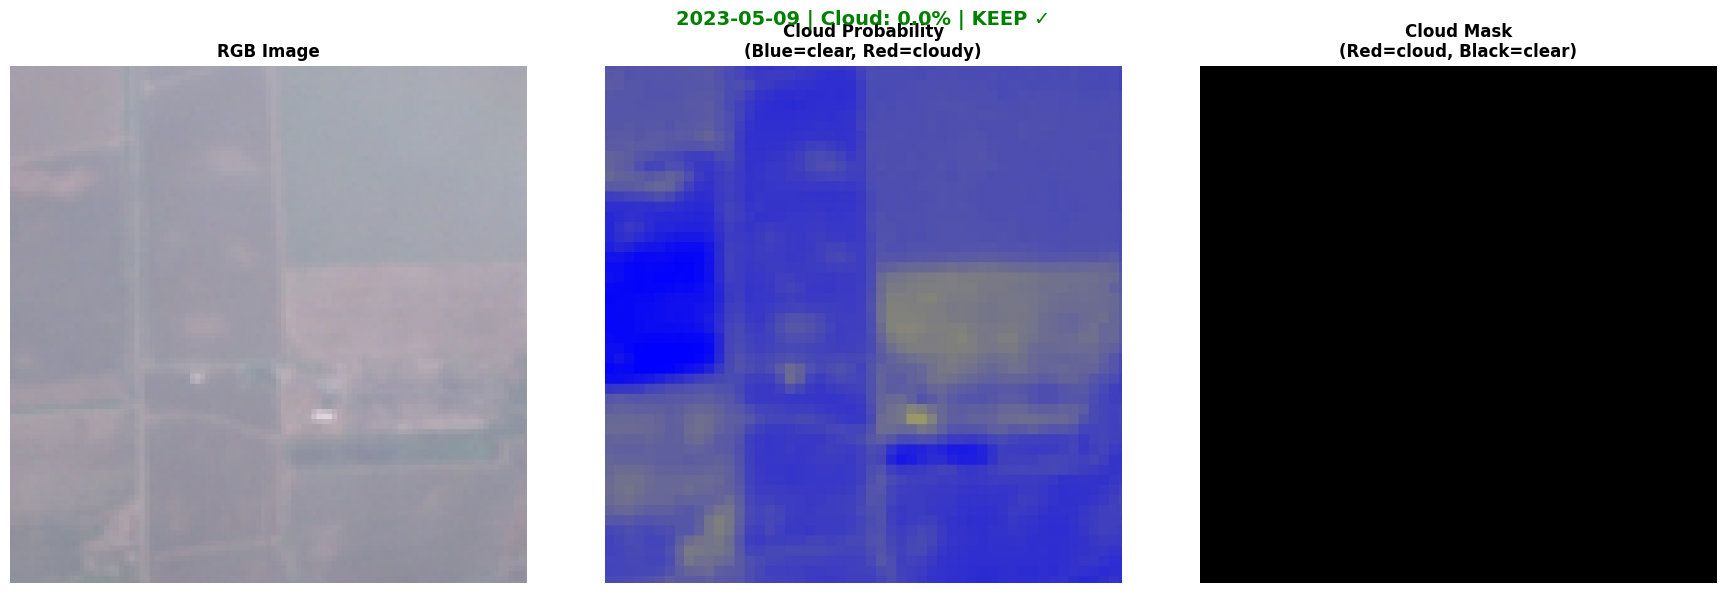

In [ ]:
def get_quality_mask(img):
    # 1. Get QA60 clouds and cirrus (bad pixels)
    qa60 = img.select('QA60')
    qa60_clouds = qa60.bitwiseAnd(1 << 10).neq(0)
    qa60_cirrus = qa60.bitwiseAnd(1 << 11).neq(0)
    
    # 2. Get custom cloud mask (bad pixels)
    custom_clouds = create_l1c_cloud_mask(img, cloud_threshold=0.55)
    
    # 3. Resample custom clouds to QA60 resolution
    custom_clouds_60m = custom_clouds.reproject(qa60_clouds.projection())
    
    # 4. Combine ALL bad pixels
    bad_pixels = qa60_clouds.Or(qa60_cirrus).Or(custom_clouds_60m.eq(1))
    
    # 5. Reduce to 2km resolution - if ANY pixel in 1km area is bad, whole area is bad
    bad_pixels_coarse = bad_pixels.reduceResolution(
        reducer=ee.Reducer.max(),  # Max = if any pixel is 1 (cloud), result is 1
        maxPixels=2048
    ).reproject(
        crs=qa60_clouds.projection().crs(),
        scale=2000  # 2km resolution
    )
    
    # 6. Resample back to 60m resolution
    bad_pixels_buffered = bad_pixels_coarse.reproject(
        crs=qa60_clouds.projection().crs(),
        scale=60
    )
    
    return bad_pixels_buffered.rename('cloud_mask')


# Test case - cloudy image
lat = 37.5
lon = -120.5
start_date = '2023-05-01'
end_date = '2023-05-11'

point = ee.Geometry.Point([lon, lat])
region = point.buffer(500).bounds()

# Get collection
col = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
       .filterBounds(region)
       .filterDate(ee.Date(start_date), ee.Date(end_date)))

print(f"Total images: {col.size().getInfo()}")

# Test each image
for i in range(col.size().getInfo()):
    img = ee.Image(col.toList(col.size()).get(i))
    img_date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    
    print(f"\n{'='*70}")
    print(f"IMAGE {i+1}: {img_date}")
    print('='*70)
    
    # Create cloud mask
    cloud_mask = get_quality_mask(img)
    
    # Calculate statistics
    stats = cloud_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=60,
        maxPixels=1e9
    ).getInfo()
    
    cloud_fraction = stats['cloud_mask']
    print(f"Cloud fraction: {cloud_fraction*100:.1f}%")
    print(f"Decision: {'REJECT ✗' if cloud_fraction > 0.15 else 'KEEP ✓'}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RGB
    rgb_vis = img.visualize(bands=['B4','B3','B2'], min=0, max=3000)
    rgb_url = rgb_vis.getThumbURL({'region': region, 'dimensions': 512})
    rgb_img = Image.open(BytesIO(requests.get(rgb_url).content))
    axes[0].imshow(rgb_img)
    axes[0].set_title('RGB Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Cloud probability (intermediate)
    blue = img.select('B2').divide(10000)
    swir = img.select('B11').divide(10000)
    vis_mean = img.select(['B2','B3','B4']).divide(10000).reduce(ee.Reducer.mean())
    p_bright = vis_mean.subtract(0.35).divide(0.15).clamp(0, 1)
    p_swir = swir.subtract(0.14).divide(0.10).clamp(0, 1)
    p_ratio = blue.divide(swir.add(1e-6)).subtract(1.5).divide(0.5).clamp(0, 1)
    cloud_prob = p_bright.multiply(0.5).add(p_swir.multiply(0.3)).add(p_ratio.multiply(0.2))
    
    prob_vis = cloud_prob.visualize(min=0, max=1, palette=['blue','yellow','red'])
    prob_url = prob_vis.getThumbURL({'region': region, 'dimensions': 512})
    prob_img = Image.open(BytesIO(requests.get(prob_url).content))
    axes[1].imshow(prob_img)
    axes[1].set_title('Cloud Probability\n(Blue=clear, Red=cloudy)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Cloud mask (final)
    mask_vis = cloud_mask.visualize(min=0, max=1, palette=['black','red'])
    mask_url = mask_vis.getThumbURL({'region': region, 'dimensions': 512})
    mask_img = Image.open(BytesIO(requests.get(mask_url).content))
    axes[2].imshow(mask_img)
    axes[2].set_title('Cloud Mask\n(Red=cloud, Black=clear)', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f"{img_date} | Cloud: {cloud_fraction*100:.1f}% | "
                f"{'REJECT ✗' if cloud_fraction > 0.15 else 'KEEP ✓'}",
                fontsize=14, fontweight='bold',
                color='red' if cloud_fraction > 0.15 else 'green')
    
    plt.tight_layout()
    plt.show()



Total images: 4

IMAGE 1: 2023-05-01
Cloud fraction: 10.0%
Decision: KEEP ✓


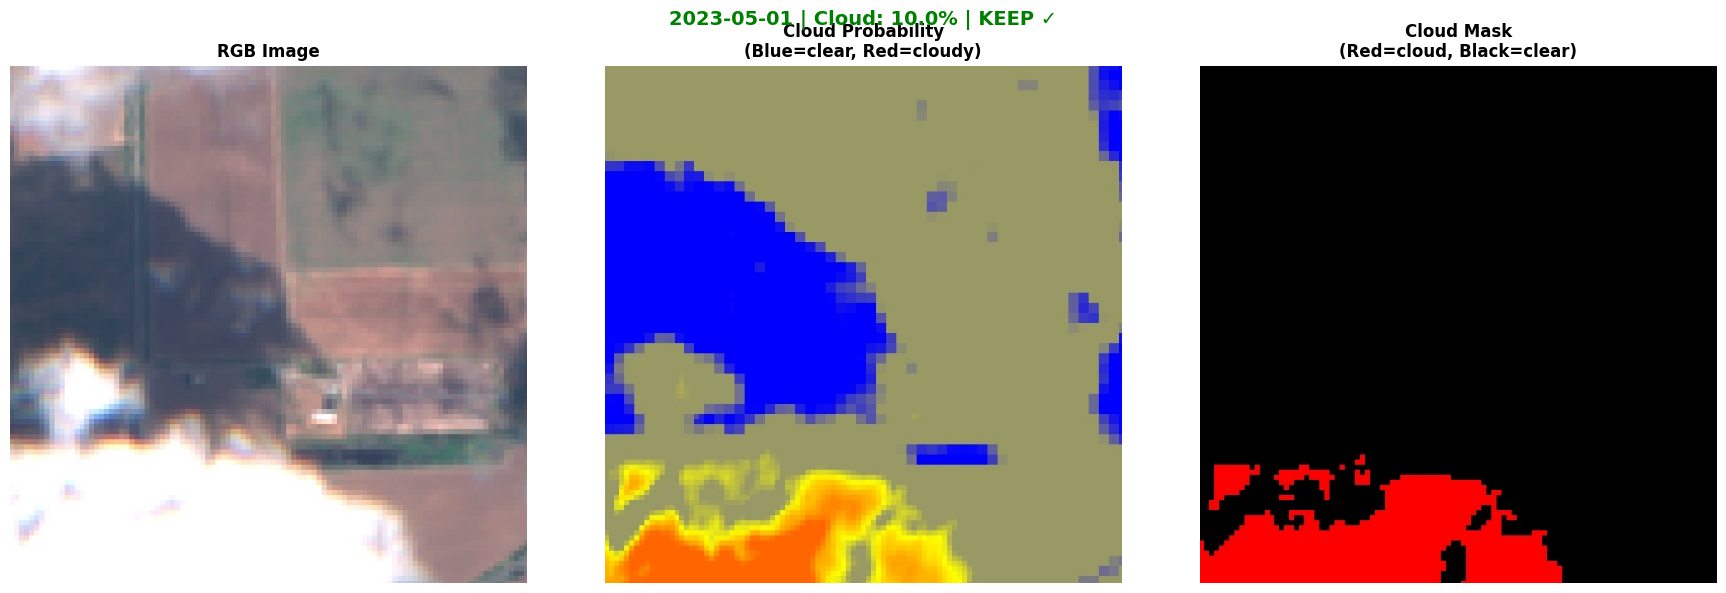


IMAGE 2: 2023-05-04
Cloud fraction: 100.0%
Decision: REJECT ✗


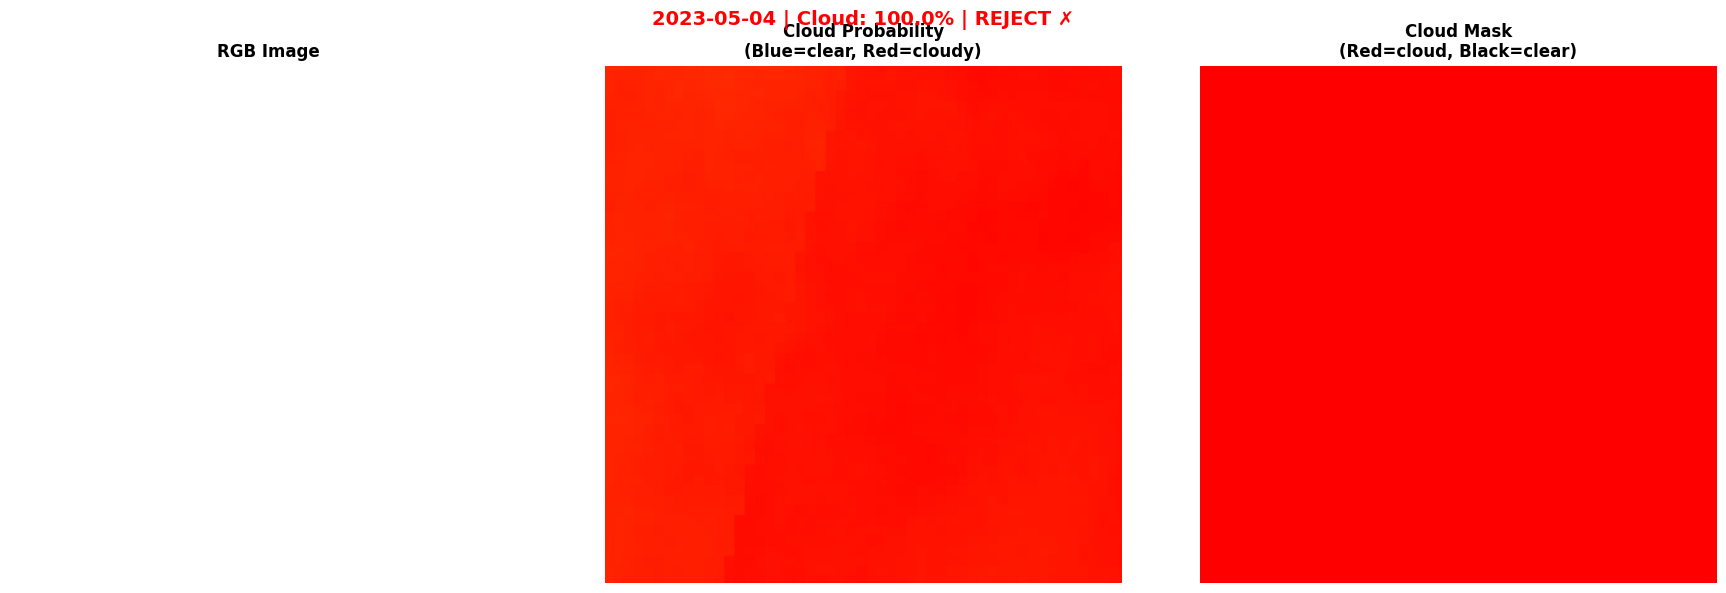


IMAGE 3: 2023-05-06
Cloud fraction: 0.0%
Decision: KEEP ✓


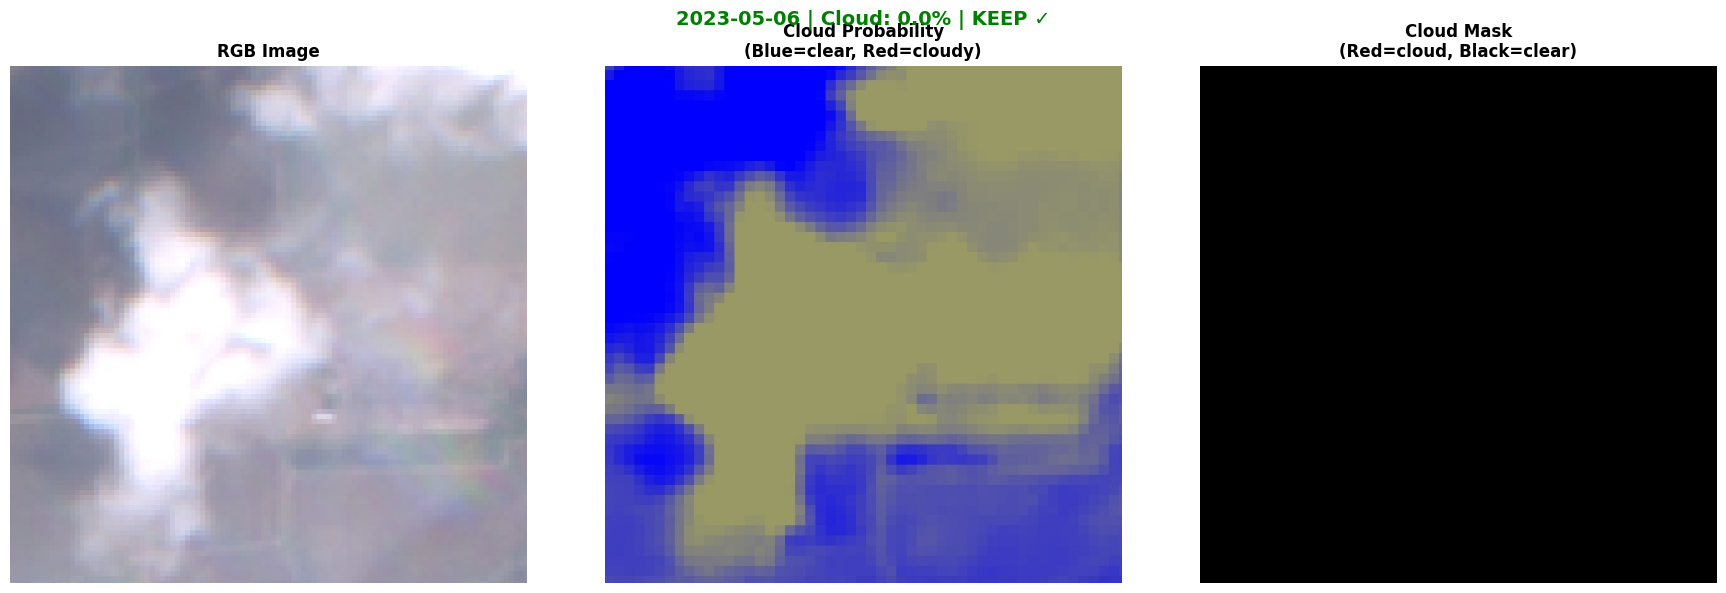


IMAGE 4: 2023-05-09
Cloud fraction: 0.0%
Decision: KEEP ✓


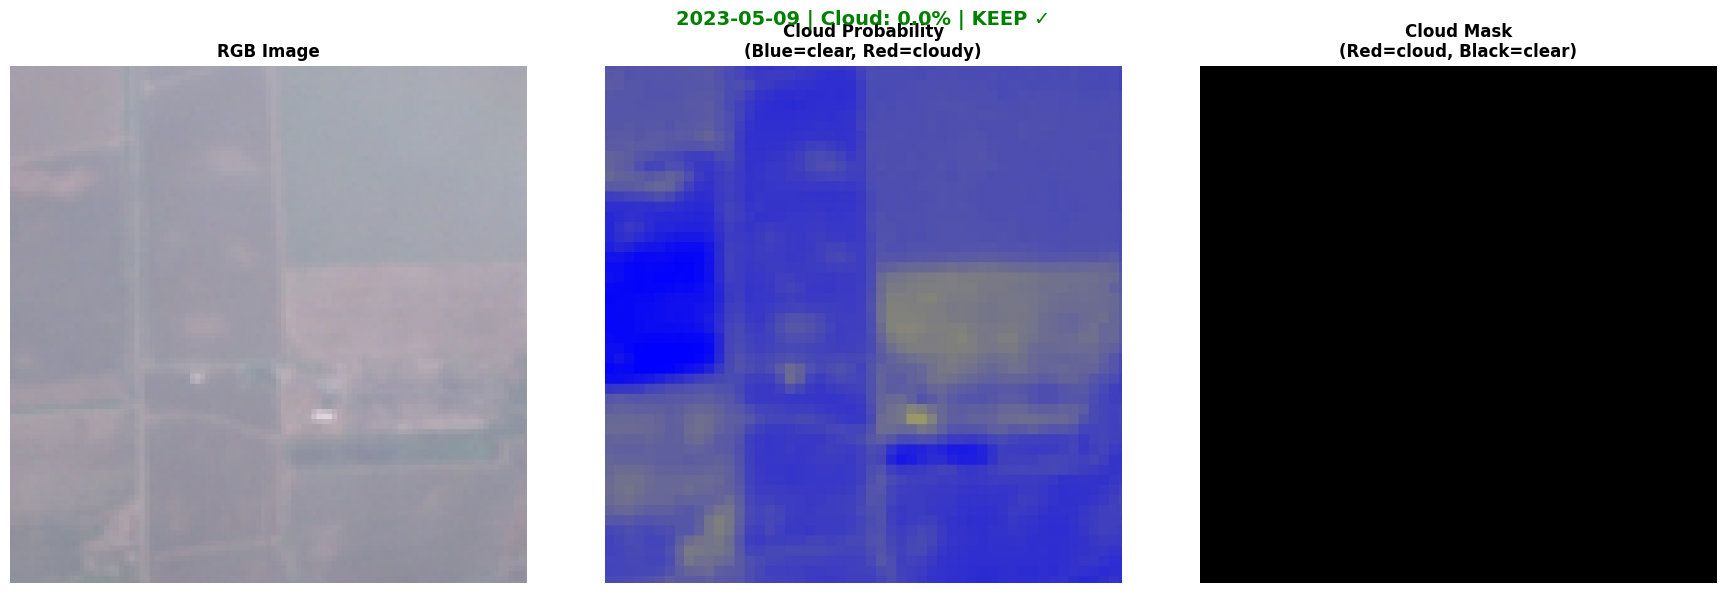

In [6]:
# Test case - cloudy image
lat = 37.5
lon = -120.5
start_date = '2023-05-01'
end_date = '2023-05-11'

point = ee.Geometry.Point([lon, lat])
region = point.buffer(500).bounds()

# Get collection
col = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
       .filterBounds(region)
       .filterDate(ee.Date(start_date), ee.Date(end_date)))

print(f"Total images: {col.size().getInfo()}")

# Test each image
for i in range(col.size().getInfo()):
    img = ee.Image(col.toList(col.size()).get(i))
    img_date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    
    print(f"\n{'='*70}")
    print(f"IMAGE {i+1}: {img_date}")
    print('='*70)
    
    # Create cloud mask
    cloud_mask = create_l1c_cloud_mask(img, cloud_threshold=0.55)
    
    # Calculate statistics
    stats = cloud_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=60,
        maxPixels=1e9
    ).getInfo()
    
    cloud_fraction = stats['cloud_mask']
    print(f"Cloud fraction: {cloud_fraction*100:.1f}%")
    print(f"Decision: {'REJECT ✗' if cloud_fraction > 0.15 else 'KEEP ✓'}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RGB
    rgb_vis = img.visualize(bands=['B4','B3','B2'], min=0, max=3000)
    rgb_url = rgb_vis.getThumbURL({'region': region, 'dimensions': 512})
    rgb_img = Image.open(BytesIO(requests.get(rgb_url).content))
    axes[0].imshow(rgb_img)
    axes[0].set_title('RGB Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Cloud probability (intermediate)
    blue = img.select('B2').divide(10000)
    swir = img.select('B11').divide(10000)
    vis_mean = img.select(['B2','B3','B4']).divide(10000).reduce(ee.Reducer.mean())
    p_bright = vis_mean.subtract(0.35).divide(0.15).clamp(0, 1)
    p_swir = swir.subtract(0.14).divide(0.10).clamp(0, 1)
    p_ratio = blue.divide(swir.add(1e-6)).subtract(1.5).divide(0.5).clamp(0, 1)
    cloud_prob = p_bright.multiply(0.5).add(p_swir.multiply(0.3)).add(p_ratio.multiply(0.2))
    
    prob_vis = cloud_prob.visualize(min=0, max=1, palette=['blue','yellow','red'])
    prob_url = prob_vis.getThumbURL({'region': region, 'dimensions': 512})
    prob_img = Image.open(BytesIO(requests.get(prob_url).content))
    axes[1].imshow(prob_img)
    axes[1].set_title('Cloud Probability\n(Blue=clear, Red=cloudy)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Cloud mask (final)
    mask_vis = cloud_mask.visualize(min=0, max=1, palette=['black','red'])
    mask_url = mask_vis.getThumbURL({'region': region, 'dimensions': 512})
    mask_img = Image.open(BytesIO(requests.get(mask_url).content))
    axes[2].imshow(mask_img)
    axes[2].set_title('Cloud Mask\n(Red=cloud, Black=clear)', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f"{img_date} | Cloud: {cloud_fraction*100:.1f}% | "
                f"{'REJECT ✗' if cloud_fraction > 0.15 else 'KEEP ✓'}",
                fontsize=14, fontweight='bold',
                color='red' if cloud_fraction > 0.15 else 'green')
    
    plt.tight_layout()
    plt.show()

